Using dataset at: /content/Final_MasterDataset_upt.csv
Dropping fully empty columns: ['Conflict_Intensity']
Dataset shape: (155, 24)
  Country  Year  D_Expenditure_GDP  Health_Expenditure_GDP  \
0     CHN  1994           1.693480                     NaN   
1     CHN  1995           1.686234                     NaN   
2     CHN  1996           1.652727                     NaN   
3     CHN  1997           1.632651                     NaN   
4     CHN  1998           1.655081                     NaN   

   Education_Expenditure_GDP  HealthExp_PerCapita_PPP_$  \
0                    1.98571                        NaN   
1                    1.84192                        NaN   
2                    1.85339                        NaN   
3                        NaN                        NaN   
4                    1.84433                        NaN   

   GovHealthExp_Pct_of_CHE  GovHealthExp_PerCapita_PPP_$  \
0                      NaN                           NaN   
1                  

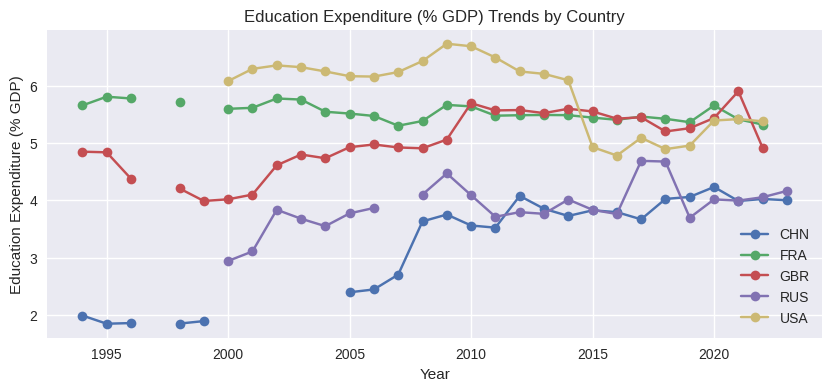

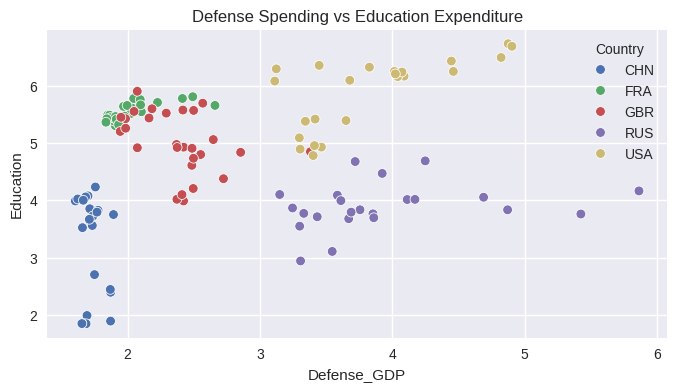

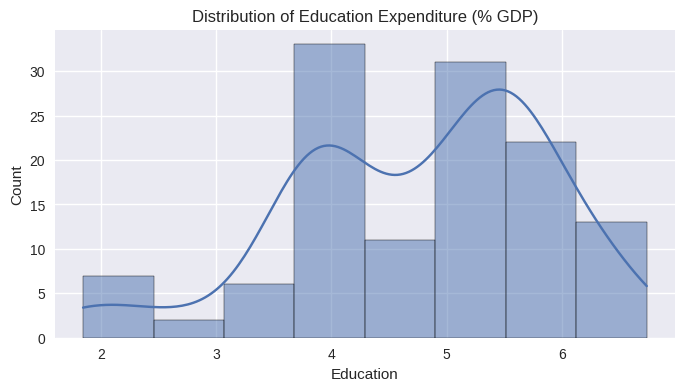


Remaining missing in features: 0
Remaining missing in target: 30

Train raw rows: 115
Test/history rows: 145

Raw sequence shapes:
X_train_raw: (46, 3, 18) y_train_raw: (46,)
X_test_raw : (30, 3, 18) y_test_raw : (30,)

Scaled sequence shapes:
X_train: (46, 3, 18) y_train: (46,)
X_test : (30, 3, 18) y_test : (30,)

Train split:
X_tr : (31, 3, 18) y_tr : (31,)
X_val: (15, 3, 18) y_val: (15,)
Epoch 1/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - loss: 0.5447 - mae: 0.5447 - val_loss: 0.3459 - val_mae: 0.3459 - learning_rate: 5.0000e-04
Epoch 2/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.4714 - mae: 0.4714 - val_loss: 0.2893 - val_mae: 0.2893 - learning_rate: 5.0000e-04
Epoch 3/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4112 - mae: 0.4112 - val_loss: 0.2418 - val_mae: 0.2418 - learning_rate: 5.0000e-04
Epoch 4/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.3570 - mae: 0.3570 - val_loss: 0.2074 - val_mae: 0.2074 - learning_rate: 5.0000e-04
Epoch 5/250
4/4 ━━━━━━━━━━━━

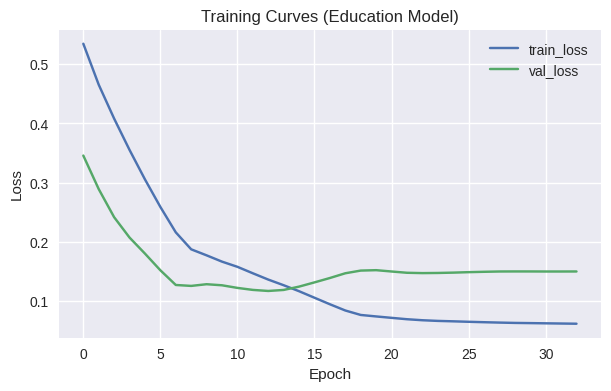


=== ONE_STEP TEST EVALUATION ===
Dropped rows due to NaNs: 0
Used rows for metrics: 30
Test MAE:  0.2570
Test RMSE: 0.3779
Test R2:   0.6762


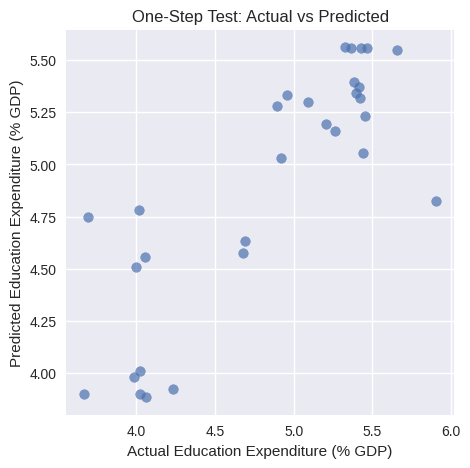


=== RECURSIVE BACKTEST (Feature Forecast Style) ===
Rows used: 30
MAE:  0.2562
RMSE: 0.3734
R2:   0.6840


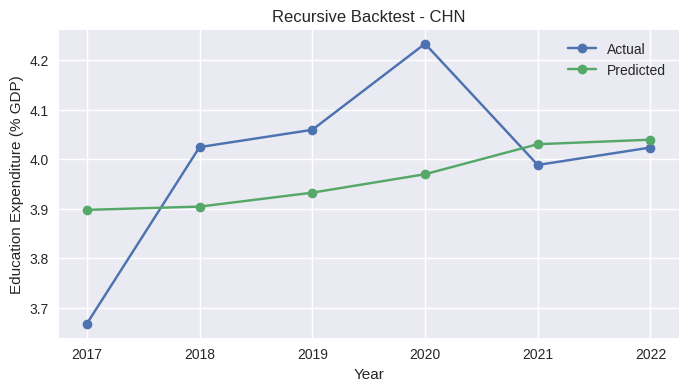

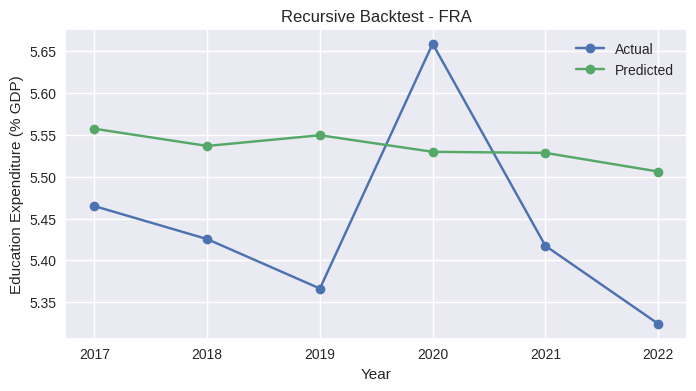

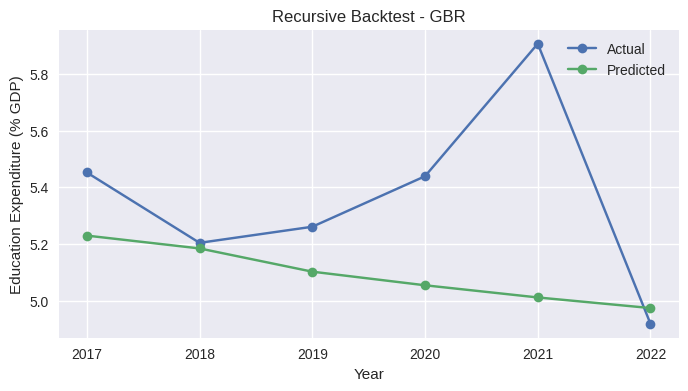

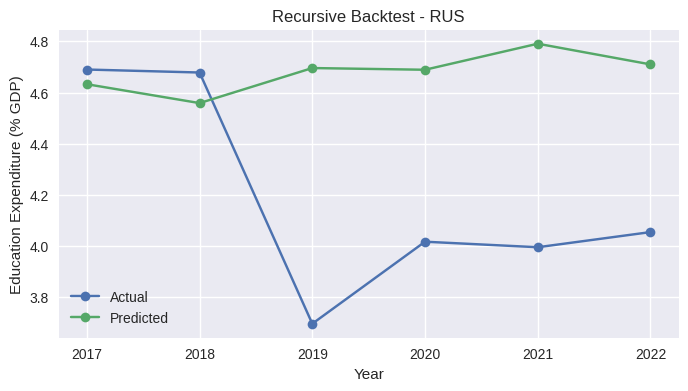

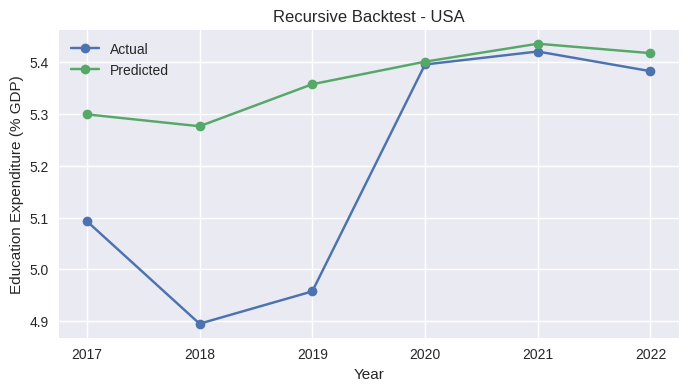


Saved files:
- education_feature_forecast_lstm_stronger.h5


In [10]:
import os
import random
from pathlib import Path
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

warnings.filterwarnings("ignore")


# Reproducibility

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# Config

TRAIN_END = 2016
TEST_START = 2017
TEST_END = 2022
VAL_START = 2014


LOOKBACK = 3

TARGET = "Education_Expenditure_GDP"


# Load Dataset

def resolve_data_path():
    candidate_paths = [
        "/content/Final_MasterDataset_upt.csv",
        "/content/Final_Master_Dataset.csv",
        "/mnt/data/Final_MasterDataset_upt.csv",
        "/mnt/data/Final_Master_Dataset.csv",
        "Final_MasterDataset_upt.csv",
        "Final_Master_Dataset.csv",
    ]
    for p in candidate_paths:
        if Path(p).exists():
            return p
    raise FileNotFoundError("CSV file not found. Upload the file first or update the path.")

def load_and_clean_dataset():
    data_path = resolve_data_path()
    print("Using dataset at:", data_path)
    df = pd.read_csv(data_path)

    # strip whitespace/newlines
    df.columns = df.columns.str.strip()

    # fix known inconsistent column names
    rename_map = {}

    if "Secondary_SclEnroll_Gross _%" in df.columns and "Secondary_SclEnroll_Gross_%" not in df.columns:
        rename_map["Secondary_SclEnroll_Gross _%"] = "Secondary_SclEnroll_Gross_%"

    for col in list(df.columns):
        if col.endswith("\n"):
            new_name = col.rstrip("\n")
            if new_name not in df.columns:
                rename_map[col] = new_name

    if rename_map:
        df = df.rename(columns=rename_map)

    # year cleanup
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"]).copy()
    df["Year"] = df["Year"].astype(int)

    # sort
    df = df.sort_values(["Country", "Year"]).reset_index(drop=True)

    # drop fully empty columns
    empty_cols = [c for c in df.columns if df[c].isna().all()]
    if empty_cols:
        print("Dropping fully empty columns:", empty_cols)
        df = df.drop(columns=empty_cols)

    print("Dataset shape:", df.shape)
    print(df.head())
    return df


# Feature Selection

def select_features(df: pd.DataFrame):
    # macro features
    base_features = [
        "Year",
        "D_Expenditure_GDP",
        "GDP_Growth_Annual",
        "Population",
        "GDP_PerCapita_Growth_Annual",
    ]

    # Education-specific features
    edu_features = [
        "Secondary_SclEnroll_Gross_%",
        "EduExp_GovShare_IMF_%",
    ]

    required_cols = ["Country"] + base_features + edu_features + [TARGET]
    missing_required = [c for c in required_cols if c not in df.columns]
    if missing_required:
        raise ValueError(f"Missing required columns for education model: {missing_required}")

    edu_df = df[required_cols].copy()
    edu_df["CountryLabel"] = edu_df["Country"]

    # replace placeholders
    edu_df = edu_df.replace(["--", "-", "—", "N/A", "na", "NaN", "", "…"], np.nan)

    # numeric conversion
    for c in base_features + edu_features + [TARGET]:
        edu_df[c] = pd.to_numeric(edu_df[c], errors="coerce")

    edu_df = edu_df.sort_values(["CountryLabel", "Year"]).reset_index(drop=True)

    print("\nSelected base features:", base_features)
    print("Selected education features:", edu_features)
    print("Target:", TARGET)

    return edu_df, base_features, edu_features


# Impute FEATURES only

def impute_feature_columns(edu_df: pd.DataFrame, feature_columns: list) -> pd.DataFrame:
    def fill_features(group: pd.DataFrame) -> pd.DataFrame:
        group = group.sort_values("Year").copy()
        group[feature_columns] = group[feature_columns].interpolate(
            method="linear", limit_direction="both"
        )
        group[feature_columns] = group[feature_columns].ffill().bfill()
        return group

    return edu_df.groupby("CountryLabel", group_keys=False).apply(fill_features)


# Add Engineered Features

def add_engineered_features(edu_df: pd.DataFrame, target: str) -> pd.DataFrame:
    df_feat = edu_df.copy()

    # target lags
    df_feat["Edu_lag1"] = df_feat.groupby("CountryLabel")[target].shift(1)
    df_feat["Edu_lag2"] = df_feat.groupby("CountryLabel")[target].shift(2)

    # defense history
    df_feat["Defense_lag1"] = df_feat.groupby("CountryLabel")["D_Expenditure_GDP"].shift(1)
    df_feat["Defense_delta"] = (
        df_feat["D_Expenditure_GDP"] - df_feat["Defense_lag1"]
    )

    # rolling education mean based only on past values
    df_feat["Edu_roll3"] = (
        df_feat.groupby("CountryLabel")[target]
        .transform(lambda s: s.shift(1).rolling(3).mean())
    )

    # short term trend
    df_feat["Edu_trend1"] = df_feat["Edu_lag1"] - df_feat["Edu_lag2"]

    return df_feat


# One Hot Encode Country

def one_hot_encode_country(df: pd.DataFrame):
    enc_df = pd.get_dummies(df, columns=["Country"], drop_first=False)
    country_cols = [c for c in enc_df.columns if c.startswith("Country_")]
    enc_df[country_cols] = enc_df[country_cols].astype("int8")
    return enc_df, country_cols


# Build Sequences

def build_raw_sequences(
    df_frame: pd.DataFrame,
    lookback: int,
    feature_cols: list,
    target_col: str,
    target_year_min: int,
    target_year_max: int,
):
    X_list, y_list = [], []
    country_meta, y_years = [], []

    for country_name, g in df_frame.groupby("CountryLabel", sort=False):
        g = g.sort_values("Year_raw").reset_index(drop=True)

        years_raw = g["Year_raw"].values
        X_vals = g[feature_cols].values.astype(float)
        y_vals = g[target_col].values.astype(float)

        for i in range(lookback, len(g)):
            y_year = years_raw[i]

            if not (target_year_min <= y_year <= target_year_max):
                continue

            # require consecutive years across lookback and target row
            window_years = years_raw[i - lookback : i + 1]
            if np.any(np.diff(window_years) != 1):
                continue

            X_seq = X_vals[i - lookback : i]

            if np.isnan(X_seq).any():
                continue

            if np.isnan(y_vals[i]):
                continue

            X_list.append(X_seq)
            y_list.append(y_vals[i])
            country_meta.append(country_name)
            y_years.append(int(y_year))

    if len(X_list) == 0:
        return (
            np.empty((0, lookback, len(feature_cols)), dtype=float),
            np.empty((0,), dtype=float),
            np.empty((0,), dtype=object),
            np.empty((0,), dtype=int),
        )

    return (
        np.array(X_list, dtype=float),
        np.array(y_list, dtype=float),
        np.array(country_meta),
        np.array(y_years, dtype=int),
    )


# Scaling Helpers

def scale_sequence_array(X_seq_raw, n_numeric, scaler_X):
    if X_seq_raw.shape[0] == 0:
        return np.empty((0, X_seq_raw.shape[1], X_seq_raw.shape[2]), dtype=float)

    X_scaled = X_seq_raw.copy().astype(float)

    num_part = X_scaled[:, :, :n_numeric].reshape(-1, n_numeric)
    num_scaled = scaler_X.transform(num_part).reshape(
        X_scaled.shape[0], X_scaled.shape[1], n_numeric
    )
    X_scaled[:, :, :n_numeric] = num_scaled

    return X_scaled

def scale_step_frame(step_df, X_COLS, scaler_X):
    step_df = step_df.copy()
    step_df[X_COLS] = scaler_X.transform(step_df[X_COLS])
    return step_df


# Simpler LSTM

def build_and_train_lstm(
    X_train,
    y_train,
    X_val,
    y_val,
    lookback,
    n_features,
    patience=20,
    lr_patience=5,
    max_epochs=250,
    batch_size=8,
):
    model = models.Sequential([
        layers.Input(shape=(lookback, n_features)),
        layers.LSTM(24),
        layers.Dense(12, activation="relu"),
        layers.Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="mae",
        metrics=["mae"]
    )

    cb_early = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    cb_reduce = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=lr_patience,
        min_lr=1e-5,
        verbose=1
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=[cb_early, cb_reduce],
        verbose=1
    )

    return model, history


# Main

def main():
    # Step 1: Load
    raw_df = load_and_clean_dataset()

    # Step 2: Select
    edu_df, base_features, edu_features = select_features(raw_df)

        # Step 2A: Quick EDA Graphs
    eda_df = edu_df[["Country", "Year", "D_Expenditure_GDP", TARGET]].copy()

    # Education trend by country
    plt.figure(figsize=(10, 4))
    for c in eda_df["Country"].dropna().unique():
        cdf = eda_df[eda_df["Country"] == c].sort_values("Year")
        plt.plot(cdf["Year"], cdf[TARGET], marker="o", label=c)

    plt.title("Education Expenditure (% GDP) Trends by Country")
    plt.xlabel("Year")
    plt.ylabel("Education Expenditure (% GDP)")
    plt.legend()
    plt.show()

    # Defense vs Education scatter
    plt.figure(figsize=(8, 4))
    scatter_df = eda_df.dropna(subset=["D_Expenditure_GDP", TARGET, "Country"]).copy()
    sns.scatterplot(
        data=scatter_df,
        x="D_Expenditure_GDP",
        y=TARGET,
        hue="Country"
    )
    plt.title("Defense Spending vs Education Expenditure")
    plt.xlabel("Defense_GDP")
    plt.ylabel("Education")
    plt.show()

    # Education distribution
    plt.figure(figsize=(8, 4))
    sns.histplot(eda_df[TARGET].dropna(), kde=True)
    plt.title("Distribution of Education Expenditure (% GDP)")
    plt.xlabel("Education")
    plt.show()

    # Step 3: Impute features only
    feature_cols = base_features + edu_features
    edu_df = impute_feature_columns(edu_df, feature_cols)

    print("\nRemaining missing in features:", int(edu_df[feature_cols].isna().sum().sum()))
    print("Remaining missing in target:", int(edu_df[TARGET].isna().sum()))

    # Step 4: Add engineered features
    edu_df = add_engineered_features(edu_df, TARGET)

    engineered_features = [
        "Edu_lag1",
        "Edu_lag2",
        "Defense_lag1",
        "Defense_delta",
        "Edu_roll3",
        "Edu_trend1",
    ]

    X_COLS = feature_cols + engineered_features

    # Step 5: One hot country
    enc_df, country_cols = one_hot_encode_country(edu_df)
    enc_df["Year_raw"] = enc_df["Year"]

    STEP_FEATURE_COLS = X_COLS + country_cols

    # Step 6: Split history
    train_enc = enc_df[enc_df["Year_raw"] <= TRAIN_END].copy()
    test_enc = enc_df[enc_df["Year_raw"] <= TEST_END].copy()

    print("\nTrain raw rows:", train_enc.shape[0])
    print("Test/history rows:", test_enc.shape[0])

    # Step 7: Build sequences
    X_train_raw, y_train_raw, train_country_meta, y_train_years = build_raw_sequences(
        df_frame=train_enc,
        lookback=LOOKBACK,
        feature_cols=STEP_FEATURE_COLS,
        target_col=TARGET,
        target_year_min=int(train_enc["Year_raw"].min()) + LOOKBACK,
        target_year_max=TRAIN_END,
    )

    X_test_raw, y_test_raw, test_country_meta, y_test_years = build_raw_sequences(
        df_frame=test_enc,
        lookback=LOOKBACK,
        feature_cols=STEP_FEATURE_COLS,
        target_col=TARGET,
        target_year_min=TEST_START,
        target_year_max=TEST_END,
    )

    print("\nRaw sequence shapes:")
    print("X_train_raw:", X_train_raw.shape, "y_train_raw:", y_train_raw.shape)
    print("X_test_raw :", X_test_raw.shape, "y_test_raw :", y_test_raw.shape)

    if X_train_raw.shape[0] == 0:
        raise ValueError("No training sequences generated. Check lookback or missing-data pattern.")

    # Step 8: Fit scalers
    n_numeric = len(X_COLS)

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    scaler_X.fit(X_train_raw[:, :, :n_numeric].reshape(-1, n_numeric))
    scaler_y.fit(y_train_raw.reshape(-1, 1))

    X_train = scale_sequence_array(X_train_raw, n_numeric, scaler_X)
    X_test = scale_sequence_array(X_test_raw, n_numeric, scaler_X)

    y_train = scaler_y.transform(y_train_raw.reshape(-1, 1)).flatten()
    y_test = scaler_y.transform(y_test_raw.reshape(-1, 1)).flatten() if len(y_test_raw) > 0 else np.array([])

    print("\nScaled sequence shapes:")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_test :", X_test.shape, "y_test :", y_test.shape)

    # Step 9: Time based validation
    val_mask = (y_train_years >= VAL_START)

    X_tr, y_tr = X_train[~val_mask], y_train[~val_mask]
    X_val, y_val = X_train[val_mask], y_train[val_mask]

    print("\nTrain split:")
    print("X_tr :", X_tr.shape, "y_tr :", y_tr.shape)
    print("X_val:", X_val.shape, "y_val:", y_val.shape)

    if X_tr.shape[0] == 0 or X_val.shape[0] == 0:
        raise ValueError("Train/validation split failed. Adjust VAL_START or inspect data.")

    # Step 10: Train model
    model, history = build_and_train_lstm(
        X_tr, y_tr,
        X_val, y_val,
        lookback=LOOKBACK,
        n_features=X_train.shape[-1],
        patience=20,
        lr_patience=5,
        max_epochs=250,
        batch_size=8,
    )

    # Step 11: Plot training curves
    plt.figure(figsize=(7, 4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Curves (Education Model)")
    plt.legend()
    plt.show()

    # Step 12: One step test evaluation
    if X_test.shape[0] == 0:
        print("\nNo test sequences generated.")
        one_step_results = pd.DataFrame()
    else:
        y_pred_scaled = model.predict(X_test, verbose=0).reshape(-1, 1)

        y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
        y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        y_true_clean = y_true[mask]
        y_pred_clean = y_pred[mask]

        print("\n=== ONE_STEP TEST EVALUATION ===")
        print("Dropped rows due to NaNs:", int((~mask).sum()))
        print("Used rows for metrics:", int(mask.sum()))

        if mask.sum() == 0:
            one_step_results = pd.DataFrame()
        else:
            mae = mean_absolute_error(y_true_clean, y_pred_clean)
            rmse_val = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
            r2 = r2_score(y_true_clean, y_pred_clean)

            print(f"Test MAE:  {mae:.4f}")
            print(f"Test RMSE: {rmse_val:.4f}")
            print(f"Test R2:   {r2:.4f}")

            one_step_results = pd.DataFrame({
                "Country": test_country_meta[mask],
                "Year": y_test_years[mask],
                "Actual_Education": y_true_clean,
                "Predicted_Education": y_pred_clean
            })

            plt.figure(figsize=(5, 5))
            plt.scatter(y_true_clean, y_pred_clean, alpha=0.7)
            plt.xlabel("Actual Education Expenditure (% GDP)")
            plt.ylabel("Predicted Education Expenditure (% GDP)")
            plt.title("One-Step Test: Actual vs Predicted")
            plt.show()

    # Step 13: Recursive backtest with trend-updated education features
    def recursive_backtest_feature_forecast():
        results = []

        countries = sorted(edu_df["CountryLabel"].unique())

        for country_name in countries:
            country_col = f"Country_{country_name}"

            c_full = enc_df[enc_df[country_col] == 1].sort_values("Year_raw").reset_index(drop=True)
            c_train = c_full[c_full["Year_raw"] <= TRAIN_END].copy()
            c_test_seq = c_full[(c_full["Year_raw"] >= TEST_START) & (c_full["Year_raw"] <= TEST_END)].copy()

            if len(c_train) < LOOKBACK or len(c_test_seq) == 0:
                continue

            seed_rows = c_train.tail(LOOKBACK).copy()

            if seed_rows[STEP_FEATURE_COLS].isna().any().any():
                print(f"Skipping {country_name}: seed contains NaNs")
                continue

            if pd.isna(c_train.iloc[-1][TARGET]) or pd.isna(c_train.iloc[-2][TARGET]):
                print(f"Skipping {country_name}: last train target values are missing")
                continue

            # initialize sequence
            seed_scaled = scale_step_frame(seed_rows[STEP_FEATURE_COLS].copy(), X_COLS, scaler_X)
            seq = seed_scaled[STEP_FEATURE_COLS].values.astype(float)

            # target history
            curr_lag1 = float(c_train.iloc[-1][TARGET])
            curr_lag2 = float(c_train.iloc[-2][TARGET])

            edu_history = c_train[TARGET].dropna().tolist()
            if len(edu_history) < 3:
                print(f"Skipping {country_name}: not enough target history for rolling mean")
                continue

            # defense history
            prev_defense = float(c_train.iloc[-1]["D_Expenditure_GDP"])

            # education feature trend estimates
            sec_vals = c_train["Secondary_SclEnroll_Gross_%"].dropna().tail(3).values
            gov_vals = c_train["EduExp_GovShare_IMF_%"].dropna().tail(3).values

            sec_val = float(sec_vals[-1]) if len(sec_vals) > 0 else 0.0
            gov_val = float(gov_vals[-1]) if len(gov_vals) > 0 else 0.0

            sec_trend = float(sec_vals[-1] - sec_vals[-2]) if len(sec_vals) >= 2 else 0.0
            gov_trend = float(gov_vals[-1] - gov_vals[-2]) if len(gov_vals) >= 2 else 0.0

            frozen = c_train.iloc[-1].copy()

            for _, actual_row in c_test_seq.iterrows():
                pred_scaled = model.predict(seq[np.newaxis, :, :], verbose=0)
                pred_edu = float(scaler_y.inverse_transform(pred_scaled.reshape(-1, 1))[0, 0])

                actual_edu = actual_row[TARGET]
                if pd.notna(actual_edu):
                    results.append({
                        "Country": country_name,
                        "Year": int(actual_row["Year_raw"]),
                        "Actual_Education": float(actual_edu),
                        "Predicted_Education": pred_edu
                    })

                current_defense = float(actual_row["D_Expenditure_GDP"])

                # simple trend update for education related exogenous features
                next_sec = sec_val + sec_trend
                next_gov = gov_val + gov_trend

                # build synthetic row for THIS year
                next_row = frozen.copy()
                next_row["Year"] = int(actual_row["Year_raw"])
                next_row["Year_raw"] = int(actual_row["Year_raw"])
                next_row["D_Expenditure_GDP"] = current_defense

                next_row["Secondary_SclEnroll_Gross_%"] = next_sec
                next_row["EduExp_GovShare_IMF_%"] = next_gov

                next_row["Edu_lag1"] = curr_lag1
                next_row["Edu_lag2"] = curr_lag2
                next_row["Defense_lag1"] = prev_defense
                next_row["Defense_delta"] = current_defense - prev_defense
                next_row["Edu_roll3"] = float(np.mean(edu_history[-3:]))
                next_row["Edu_trend1"] = curr_lag1 - curr_lag2

                next_row_df = pd.DataFrame([next_row])[STEP_FEATURE_COLS].copy()
                next_row_scaled = scale_step_frame(next_row_df, X_COLS, scaler_X)

                seq = np.vstack([seq[1:], next_row_scaled[STEP_FEATURE_COLS].values.astype(float)])

                # advance states
                curr_lag2 = curr_lag1
                curr_lag1 = pred_edu
                edu_history.append(pred_edu)

                prev_defense = current_defense
                sec_val = next_sec
                gov_val = next_gov

                frozen["Year"] = int(actual_row["Year_raw"])
                frozen["Year_raw"] = int(actual_row["Year_raw"])
                frozen["D_Expenditure_GDP"] = current_defense
                frozen["Secondary_SclEnroll_Gross_%"] = next_sec
                frozen["EduExp_GovShare_IMF_%"] = next_gov

        return pd.DataFrame(results)

    backtest_results = recursive_backtest_feature_forecast()

    if backtest_results.empty:
        print("\nNo recursive backtest rows produced.")
    else:
        mae_rec = mean_absolute_error(
            backtest_results["Actual_Education"],
            backtest_results["Predicted_Education"]
        )
        rmse_rec = np.sqrt(mean_squared_error(
            backtest_results["Actual_Education"],
            backtest_results["Predicted_Education"]
        ))
        r2_rec = r2_score(
            backtest_results["Actual_Education"],
            backtest_results["Predicted_Education"]
        )

        print("\n=== RECURSIVE BACKTEST (Feature Forecast Style) ===")
        print(f"Rows used: {len(backtest_results)}")
        print(f"MAE:  {mae_rec:.4f}")
        print(f"RMSE: {rmse_rec:.4f}")
        print(f"R2:   {r2_rec:.4f}")

        for c in sorted(backtest_results["Country"].unique()):
            cdf = backtest_results[backtest_results["Country"] == c].sort_values("Year")

            plt.figure(figsize=(8, 4))
            plt.plot(cdf["Year"], cdf["Actual_Education"], marker="o", label="Actual")
            plt.plot(cdf["Year"], cdf["Predicted_Education"], marker="o", label="Predicted")
            plt.title(f"Recursive Backtest - {c}")
            plt.xlabel("Year")
            plt.ylabel("Education Expenditure (% GDP)")
            plt.legend()
            plt.show()

    # Step 14: Future scenario forecast
    def forecast_future_education(country_name: str, target_year: int, defense_gdp_value: float) -> pd.DataFrame:
        country_col = f"Country_{country_name}"

        if country_col not in enc_df.columns:
            raise ValueError(f"Unknown country: {country_name}")

        c = enc_df[enc_df[country_col] == 1].sort_values("Year_raw").reset_index(drop=True)

        if len(c) < LOOKBACK:
            raise ValueError(f"Not enough history for {country_name}")

        if pd.isna(c.iloc[-1][TARGET]) or pd.isna(c.iloc[-2][TARGET]):
            raise ValueError(f"Last known target values for {country_name} are missing")

        last_available_year = int(c.iloc[-1]["Year_raw"])
        if target_year <= last_available_year:
            raise ValueError(f"target_year must be greater than {last_available_year}")

        seed_rows = c.tail(LOOKBACK).copy()
        if seed_rows[STEP_FEATURE_COLS].isna().any().any():
            raise ValueError(f"Seed rows for {country_name} contain NaNs")

        seed_scaled = scale_step_frame(seed_rows[STEP_FEATURE_COLS].copy(), X_COLS, scaler_X)
        seq = seed_scaled[STEP_FEATURE_COLS].values.astype(float)

        curr_lag1 = float(c.iloc[-1][TARGET])
        curr_lag2 = float(c.iloc[-2][TARGET])

        edu_history = c[TARGET].dropna().tolist()
        if len(edu_history) < 3:
            raise ValueError(f"Not enough target history for {country_name}")

        prev_defense = float(c.iloc[-1]["D_Expenditure_GDP"])

        sec_vals = c["Secondary_SclEnroll_Gross_%"].dropna().tail(3).values
        gov_vals = c["EduExp_GovShare_IMF_%"].dropna().tail(3).values

        sec_val = float(sec_vals[-1]) if len(sec_vals) > 0 else 0.0
        gov_val = float(gov_vals[-1]) if len(gov_vals) > 0 else 0.0

        sec_trend = float(sec_vals[-1] - sec_vals[-2]) if len(sec_vals) >= 2 else 0.0
        gov_trend = float(gov_vals[-1] - gov_vals[-2]) if len(gov_vals) >= 2 else 0.0

        frozen_state = c.iloc[-1].copy()
        future_rows = []

        for yr in range(last_available_year + 1, target_year + 1):
            pred_scaled = model.predict(seq[np.newaxis, :, :], verbose=0)
            pred_edu = float(scaler_y.inverse_transform(pred_scaled.reshape(-1, 1))[0, 0])

            future_rows.append({
                "Country": country_name,
                "Year": yr,
                "Input_Defense_GDP": float(defense_gdp_value),
                "Predicted_Education_Expenditure_GDP": pred_edu
            })

            next_sec = sec_val + sec_trend
            next_gov = gov_val + gov_trend

            next_row = frozen_state.copy()
            next_row["Year"] = yr
            next_row["Year_raw"] = yr
            next_row["D_Expenditure_GDP"] = float(defense_gdp_value)

            next_row["Secondary_SclEnroll_Gross_%"] = next_sec
            next_row["EduExp_GovShare_IMF_%"] = next_gov

            next_row["Edu_lag1"] = curr_lag1
            next_row["Edu_lag2"] = curr_lag2
            next_row["Defense_lag1"] = prev_defense
            next_row["Defense_delta"] = float(defense_gdp_value) - prev_defense
            next_row["Edu_roll3"] = float(np.mean(edu_history[-3:]))
            next_row["Edu_trend1"] = curr_lag1 - curr_lag2

            next_row_df = pd.DataFrame([next_row])[STEP_FEATURE_COLS].copy()
            next_row_scaled = scale_step_frame(next_row_df, X_COLS, scaler_X)

            seq = np.vstack([seq[1:], next_row_scaled[STEP_FEATURE_COLS].values.astype(float)])

            curr_lag2 = curr_lag1
            curr_lag1 = pred_edu
            edu_history.append(pred_edu)

            prev_defense = float(defense_gdp_value)
            sec_val = next_sec
            gov_val = next_gov

            frozen_state["Year"] = yr
            frozen_state["Year_raw"] = yr
            frozen_state["D_Expenditure_GDP"] = float(defense_gdp_value)
            frozen_state["Secondary_SclEnroll_Gross_%"] = next_sec
            frozen_state["EduExp_GovShare_IMF_%"] = next_gov

        return pd.DataFrame(future_rows)

    def forecast_multiple_countries(country_list, target_year, defense_gdp_value):
        outputs = []
        for country_name in country_list:
            outputs.append(
                forecast_future_education(country_name, target_year, defense_gdp_value)
            )
        return pd.concat(outputs, ignore_index=True) if outputs else pd.DataFrame()


    # Step 15: Save Model
    model.save("education_feature_forecast_lstm_stronger.h5", save_format="h5")
    # joblib.dump(scaler_X, "education_x_scaler.pkl")
    # joblib.dump(scaler_y, "education_y_scaler.pkl")

    # metadata = {
    #     "target": TARGET,
    #     "base_features": base_features,
    #     "edu_features": edu_features,
    #     "engineered_features": engineered_features,
    #     "x_cols": X_COLS,
    #     "country_cols": country_cols,
    #     "step_feature_cols": STEP_FEATURE_COLS,
    #     "lookback": LOOKBACK,
    #     "train_years": (int(train_enc["Year_raw"].min()), TRAIN_END),
    #     "val_years": (VAL_START, TRAIN_END),
    #     "test_years": (TEST_START, TEST_END),
    #     "countries": sorted(edu_df["CountryLabel"].unique().tolist()),
    # }
    # joblib.dump(metadata, "education_feature_forecast_metadata.pkl")

    # enc_df.to_csv("education_feature_forecast_processed.csv", index=False)

    print("\nSaved files:")
    print("- education_feature_forecast_lstm_stronger.h5")
    # print("- education_x_scaler.pkl")
    # print("- education_y_scaler.pkl")
    # print("- education_feature_forecast_metadata.pkl")
    # print("- education_feature_forecast_processed.csv")


# Run

if __name__ == "__main__":
    main()